In [ ]:
# Import essential libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print the shape of the data
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [ ]:
# Reshape the data to include channel dimension (grayscale -> 1 channel)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

In [ ]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [ ]:
# One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Check the shape
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)


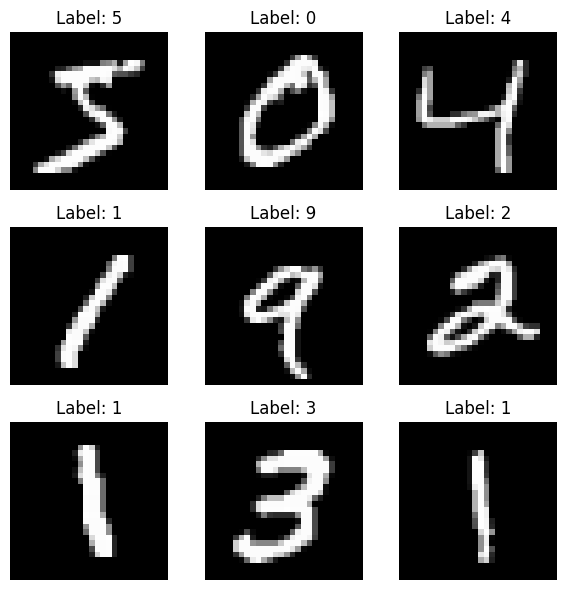

In [ ]:
# Visualize the first 9 digits
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

  # This code displays the first 9 images from the training set in a 3×3 grid,
  # showing each handwritten digit in grayscale along with its correct label,
  # helping us visually check that the data is loaded and labeled correctly.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # to reduce overfitting
    Dense(10, activation='softmax')  # 10 output classes for digits 0–9
])

# Model summary
model


<Sequential name=sequential_1, built=True>

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

Epoch 1/5
422/422 - 41s - 98ms/step - accuracy: 0.9853 - loss: 0.0493 - val_accuracy: 0.9905 - val_loss: 0.0345
Epoch 2/5
422/422 - 41s - 96ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9903 - val_loss: 0.0333
Epoch 3/5
422/422 - 41s - 96ms/step - accuracy: 0.9888 - loss: 0.0367 - val_accuracy: 0.9903 - val_loss: 0.0380
Epoch 4/5
422/422 - 41s - 97ms/step - accuracy: 0.9891 - loss: 0.0340 - val_accuracy: 0.9915 - val_loss: 0.0317
Epoch 5/5
422/422 - 41s - 97ms/step - accuracy: 0.9907 - loss: 0.0310 - val_accuracy: 0.9912 - val_loss: 0.0347


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9921 - loss: 0.0248
Test Accuracy: 0.9921
Test Loss: 0.0248


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict the classes
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



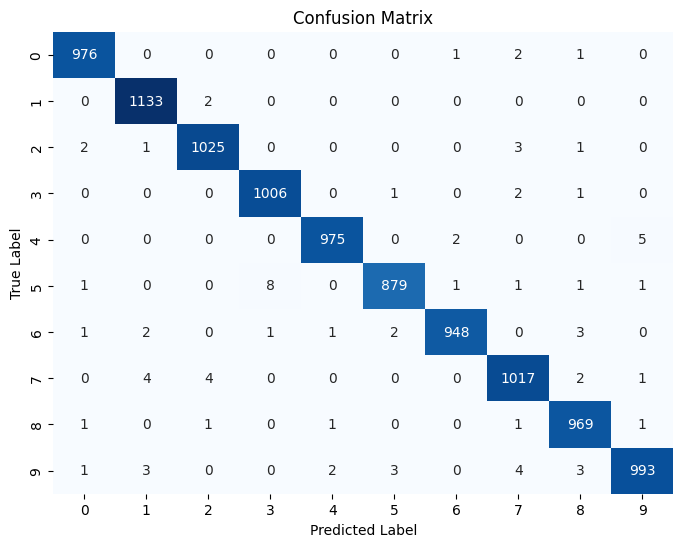

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Predict class probabilities for test images
predictions = model.predict(x_test)

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


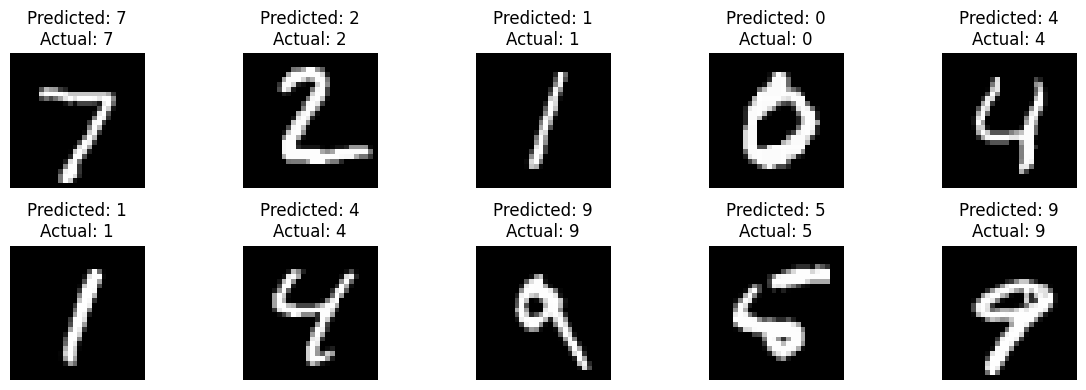

In [ ]:
# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_classes[i]}\nActual: {true_classes[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# This code shows 10 test images side by side, displaying each image’s predicted label
# and its actual label, so you can visually compare how well the CNN is performing on unseen data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


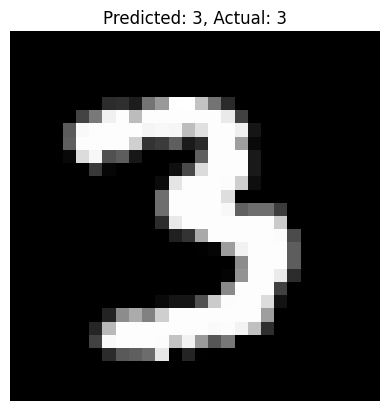

In [ ]:
# Predict a single image (e.g., index 500)
index = 500
single_image = x_test[index].reshape(1, 28, 28, 1)

# Predict and show result
predicted_label = np.argmax(model.predict(single_image))
actual_label = np.argmax(y_test[index])

plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
plt.axis('off')
plt.show()

# This code picks one test image (at index 500), lets the trained CNN predict its digit,
# compares it with the actual label, and
# then displays the image showing both the predicted and actual digits for easy verification.